In [25]:
landmark_path = 'D:\\IDE Repo\\Dl-net\\data\\casme2-preprocessed-v2\\face_landmarks.csv'

In [26]:
import pandas as pd

df = pd.read_csv(landmark_path)
print(f"Number of rows   : {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}\n")

df.head()

Number of rows   : 500
Number of columns: 1436



,filepath,landmarks_detected,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,...,z_474,x_475,y_475,z_475,x_476,y_476,z_476,x_477,y_477,z_477
0,./data/casme2-preprocessed-v2\CASME2 Preproces...,478,0.514768,0.722219,-0.136648,0.523118,0.576818,-0.294961,0.517824,0.617790,...,0.025961,0.768488,0.236143,0.025960,0.713368,0.271990,0.025894,0.768613,0.307834,0.025907
1,./data/casme2-preprocessed-v2\CASME2 Preproces...,478,0.503075,0.703677,-0.148351,0.493394,0.541940,-0.285421,0.497619,0.590272,...,0.017879,0.768665,0.234639,0.017880,0.715009,0.270061,0.017815,0.770119,0.305565,0.017829
2,./data/casme2-preprocessed-v2\CASME2 Preproces...,478,0.500352,0.686904,-0.110848,0.499011,0.567026,-0.270116,0.498298,0.594931,...,0.000029,0.764490,0.239815,0.000024,0.711010,0.275667,-0.000036,0.763916,0.310359,-0.000028
3,./data/casme2-preprocessed-v2\CASME2 Preproces...,478,0.501748,0.691448,-0.144714,0.504308,0.553497,-0.295761,0.501742,0.600460,...,0.034370,0.796956,0.252263,0.034371,0.740294,0.285858,0.034301,0.794857,0.321623,0.034317
4,./data/casme2-preprocessed-v2\CASME2 Preproces...,478,0.485267,0.679308,-0.135492,0.496794,0.537978,-0.274870,0.493410,0.576039,...,0.013004,0.766617,0.254572,0.013000,0.715819,0.286032,0.012945,0.764681,0.318232,0.012957


## Fix Data Path

In [27]:
print(f"Old Filepath: {df['filepath'][0]}")
df['filepath'] = df['filepath'].apply(lambda x: x.replace('\\', '/'))
print(f"New Filepath: {df['filepath'][0]}")

Old Filepath: ./data/casme2-preprocessed-v2\CASME2 Preprocessed v2\others\reg_img65 (24).jpg
New Filepath: ./data/casme2-preprocessed-v2/CASME2 Preprocessed v2/others/reg_img65 (24).jpg


## Check Image working or not

In [28]:
import os

def find_project_root(marker='data'):
    path = os.getcwd()
    while path != os.path.dirname(path):  # stop at filesystem root
        if os.path.isdir(os.path.join(path, marker)):
            return path
        path = os.path.dirname(path)
    raise FileNotFoundError(f"Could not find '{marker}' folder above {os.getcwd()}")

BASE_DIR = find_project_root('data')
print(BASE_DIR)

df['filepath'] = df['filepath'].apply(
    lambda x: os.path.join(BASE_DIR, x.replace('\\', '/').lstrip('./')).replace('\\', '/')
)

df['filepath'][0]
# 'd:/IDE Repo/Dl-net/data/casme2-preprocessed-v2/CASME2 Preprocessed v2/others/reg_img65 (24).jpg'

d:\IDE Repo\Dl-net


'd:/IDE Repo/Dl-net/data/casme2-preprocessed-v2/CASME2 Preprocessed v2/others/reg_img65 (24).jpg'

In [30]:
print("--- DETECTION SUCCESS RATE ---")
detection_counts = df['landmarks_detected'].value_counts(normalize=True) * 100
print(detection_counts.to_string(float_format="%.2f%%"))

print("\n--- MISSING VALUES (NaNs) ---")
missing_counts = df.isnull().sum()
cols_with_missing = missing_counts[missing_counts > 0]

if cols_with_missing.empty:
    print("No missing values found.")
else:
    print(f"⚠️ Found {len(cols_with_missing)} columns with missing values.")
    display(cols_with_missing.head(10))

--- DETECTION SUCCESS RATE ---
landmarks_detected
478   100.00%

--- MISSING VALUES (NaNs) ---
No missing values found.


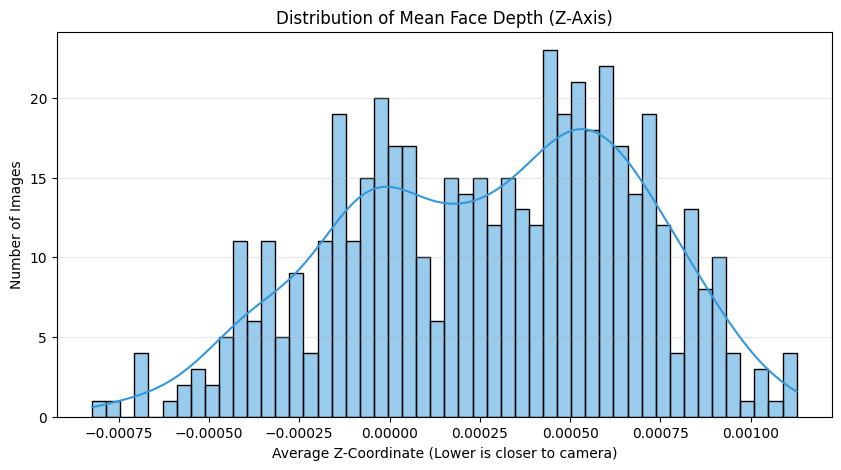

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

z_cols = [col for col in df.columns if col.startswith('z_')]

df['mean_face_depth'] = df[z_cols].mean(axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(df['mean_face_depth'], bins=50, kde=True, color='#3498db')
plt.title('Distribution of Mean Face Depth (Z-Axis)')
plt.xlabel('Average Z-Coordinate (Lower is closer to camera)')
plt.ylabel('Number of Images')
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\Sad Bin Siddique\AppData\Local\Temp\ipykernel_24548\3318677582.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['mouth_opening'] = np.sqrt(


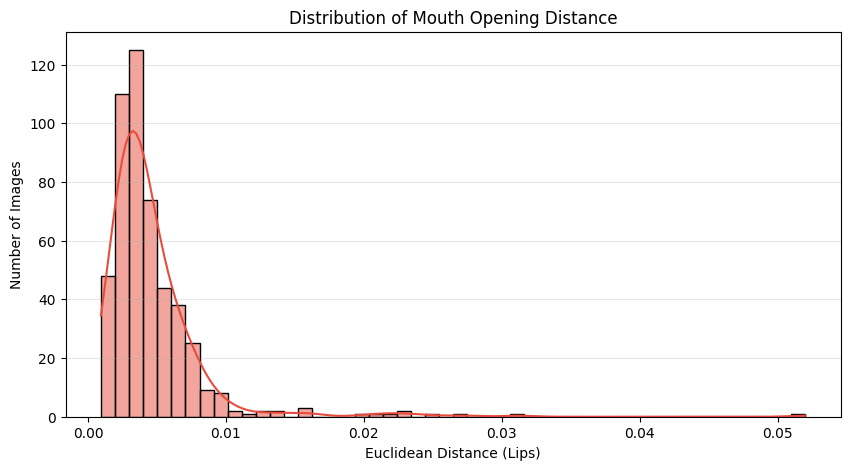

Images with the widest open mouths:


,filepath,mouth_opening
205,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.052013
123,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.031178
337,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.027364
92,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.024893
95,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.023176


In [35]:
import numpy as np

df['mouth_opening'] = np.sqrt(
    (df['x_13'] - df['x_14'])**2 + 
    (df['y_13'] - df['y_14'])**2 + 
    (df['z_13'] - df['z_14'])**2
)

plt.figure(figsize=(10, 5))
sns.histplot(df['mouth_opening'], bins=50, kde=True, color='#e74c3c')
plt.title('Distribution of Mouth Opening Distance')
plt.xlabel('Euclidean Distance (Lips)')
plt.ylabel('Number of Images')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Show the top 5 images with the widest open mouths
print("Images with the widest open mouths:")
display(df[['filepath', 'mouth_opening']].sort_values(by='mouth_opening', ascending=False).head())

In [37]:
df


,filepath,landmarks_detected,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,...,x_476,y_476,z_476,x_477,y_477,z_477,mean_face_depth,mouth_opening,lip_stretch,eyebrow_raise
0,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,478,0.514768,0.722219,-0.136648,0.523118,0.576818,-0.294961,0.517824,0.617790,...,0.713368,0.271990,0.025894,0.768613,0.307834,0.025907,0.000152,0.001302,0.459900,0.204242
1,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,478,0.503075,0.703677,-0.148351,0.493394,0.541940,-0.285421,0.497619,0.590272,...,0.715009,0.270061,0.017815,0.770119,0.305565,0.017829,0.000338,0.009676,0.451755,0.185571
2,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,478,0.500352,0.686904,-0.110848,0.499011,0.567026,-0.270116,0.498298,0.594931,...,0.711010,0.275667,-0.000036,0.763916,0.310359,-0.000028,-0.000176,0.003420,0.411857,0.178837
3,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,478,0.501748,0.691448,-0.144714,0.504308,0.553497,-0.295761,0.501742,0.600460,...,0.740294,0.285858,0.034301,0.794857,0.321623,0.034317,0.000322,0.005172,0.482519,0.239409
4,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,478,0.485267,0.679308,-0.135492,0.496794,0.537978,-0.274870,0.493410,0.576039,...,0.715819,0.286032,0.012945,0.764681,0.318232,0.012957,0.000139,0.005156,0.404620,0.177708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,478,0.516657,0.675694,-0.130657,0.518501,0.540764,-0.281543,0.515086,0.578404,...,0.696221,0.277099,0.029691,0.745791,0.308880,0.029701,0.000208,0.002239,0.425699,0.188357
496,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,478,0.484307,0.685404,-0.135469,0.491983,0.552263,-0.285631,0.493171,0.590522,...,0.719425,0.282066,0.016491,0.774080,0.317411,0.016502,0.000200,0.004974,0.442305,0.174555
497,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,478,0.487035,0.678071,-0.117654,0.489975,0.545326,-0.271894,0.490257,0.580739,...,0.717928,0.272959,-0.005871,0.770138,0.307758,-0.005858,-0.000311,0.005597,0.390361,0.201511
498,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,478,0.515197,0.685630,-0.123438,0.515362,0.559473,-0.277565,0.513337,0.594185,...,0.723376,0.271711,0.015668,0.776862,0.306473,0.015678,-0.000029,0.003622,0.441271,0.171010


Extracting Micro-Expression Features...


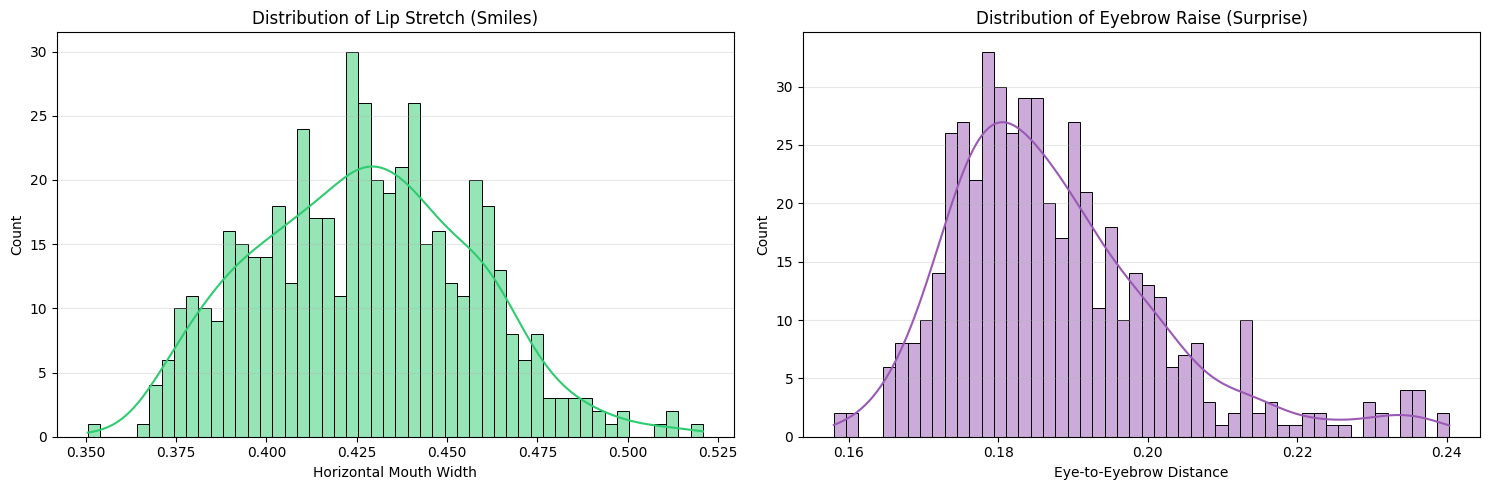

,filepath,mouth_opening,lip_stretch,eyebrow_raise
0,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.001302,0.459900,0.204242
1,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.009676,0.451755,0.185571
2,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.003420,0.411857,0.178837
3,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.005172,0.482519,0.239409
4,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.005156,0.404620,0.177708


In [47]:
print("Extracting Micro-Expression Features...")

df['lip_stretch'] = np.sqrt(
    (df['x_61'] - df['x_291'])**2 + 
    (df['y_61'] - df['y_291'])**2 + 
    (df['z_61'] - df['z_291'])**2
)

df['eyebrow_raise'] = np.sqrt(
    (df['x_159'] - df['x_105'])**2 + 
    (df['y_159'] - df['y_105'])**2 + 
    (df['z_159'] - df['z_105'])**2
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['lip_stretch'], bins=50, kde=True, color='#2ecc71', ax=axes[0])
axes[0].set_title('Distribution of Lip Stretch (Smiles)')
axes[0].set_xlabel('Horizontal Mouth Width')
axes[0].grid(axis='y', alpha=0.3)

sns.histplot(df['eyebrow_raise'], bins=50, kde=True, color='#9b59b6', ax=axes[1])
axes[1].set_title('Distribution of Eyebrow Raise (Surprise)')
axes[1].set_xlabel('Eye-to-Eyebrow Distance')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

display(df[['filepath', 'mouth_opening', 'lip_stretch', 'eyebrow_raise']].head())

In [50]:
lip_mean, lip_std = df['lip_stretch'].mean(), df['lip_stretch'].std()
eye_mean, eye_std = df['eyebrow_raise'].mean(), df['eyebrow_raise'].std()

lip_threshold = lip_mean + lip_std
eye_threshold = eye_mean + eye_std

print(f"Smile Threshold (Lip Stretch): > {lip_threshold:.4f}")
print(f"Surprise Threshold (Eyebrow Raise): > {eye_threshold:.4f}\n")

def guess_expression(row):
    if row['lip_stretch'] > lip_threshold and row['eyebrow_raise'] > eye_threshold:
        lip_z_score = (row['lip_stretch'] - lip_mean) / lip_std
        eye_z_score = (row['eyebrow_raise'] - eye_mean) / eye_std
        return "Happiness" if lip_z_score > eye_z_score else "Surprise"
        
    elif row['lip_stretch'] > lip_threshold:
        return "Happiness"
    elif row['eyebrow_raise'] > eye_threshold:
        return "Surprise"
    else:
        return "Neutral / Other"

df['heuristic_prediction'] = df.apply(guess_expression, axis=1)

print("--- Baseline Predictions ---")
print(df['heuristic_prediction'].value_counts())
display(df[['filepath', 'lip_stretch', 'eyebrow_raise', 'heuristic_prediction']].sample(10))

Smile Threshold (Lip Stretch): > 0.4567
Surprise Threshold (Eyebrow Raise): > 0.2024

--- Baseline Predictions ---
heuristic_prediction
Neutral / Other    373
Happiness           69
Surprise            58
Name: count, dtype: int64


,filepath,lip_stretch,eyebrow_raise,heuristic_prediction
287,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.433481,0.175823,Neutral / Other
425,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.480885,0.212707,Happiness
370,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.457273,0.208628,Surprise
477,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.391401,0.176871,Neutral / Other
393,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.520877,0.192377,Happiness
380,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.476170,0.203694,Happiness
3,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.482519,0.239409,Surprise
286,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.442214,0.182045,Neutral / Other
32,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.456646,0.183744,Neutral / Other
432,d:/IDE Repo/Dl-net/data/casme2-preprocessed-v2...,0.402738,0.177256,Neutral / Other


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px
from IPython.display import display

print("Preparing Data for Machine Learning...")

features = ['mouth_opening', 'lip_stretch', 'eyebrow_raise']
X = df[features]

# 2. Scale the data 
# (Machine learning algorithms need all features to be on the same scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply K-Means Clustering
# Let's tell the AI to look for 3 distinct groups (e.g., Neutral, Smile, Surprise)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['ai_cluster'] = kmeans.fit_predict(X_scaled)

# 4. Give the clusters readable names so we can understand the plot
# (Note: The AI doesn't know the names of emotions, it just knows group 0, 1, and 2. 
# We will just label them as Cluster 0, 1, 2 for now).
df['ai_cluster_name'] = df['ai_cluster'].map({0: 'Cluster A', 1: 'Cluster B', 2: 'Cluster C'})

print("Clustering Complete! Visualizing the AI's groupings...")

# 5. Visualize the AI's clusters in an interactive 3D plot
fig = px.scatter_3d(
    df, 
    x='lip_stretch', 
    y='eyebrow_raise', 
    z='mouth_opening',
    color='ai_cluster_name',
    hover_name='filepath',
    title="AI Discovered Expression Clusters (K-Means)",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

# 6. Compare the AI's clusters against our human rules
print("\n--- Comparing AI Clusters to Human Rules ---")
display(pd.crosstab(df['ai_cluster_name'], df['heuristic_prediction']))

Preparing Data for Machine Learning...
Clustering Complete! Visualizing the AI's groupings...



--- Comparing AI Clusters to Human Rules ---


heuristic_prediction,Happiness,Neutral / Other,Surprise
ai_cluster_name,,,
Cluster A,55,17,51
Cluster B,11,347,6
Cluster C,3,9,1


In [52]:
print("--- 1. Auto-Labeling based on AI Clusters ---")
cluster_to_emotion = {
    'Cluster A': 'Neutral',
    'Cluster B': 'Happiness',
    'Cluster C': 'Surprise'
}

df['emotion_label'] = df['ai_cluster_name'].map(cluster_to_emotion)
print("Labels successfully applied! Distribution:")
print(df['emotion_label'].value_counts())


--- 1. Auto-Labeling based on AI Clusters ---
Labels successfully applied! Distribution:
emotion_label
Happiness    364
Neutral      123
Surprise      13
Name: count, dtype: int64


C:\Users\Sad Bin Siddique\AppData\Local\Temp\ipykernel_24548\1208017922.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['emotion_label'] = df['ai_cluster_name'].map(cluster_to_emotion)


In [60]:
from sklearn.model_selection import train_test_split

# Define our inputs (X) and our target to predict (y)
features = ['mouth_opening', 'lip_stretch', 'eyebrow_raise']

X = df[features]
y = df['emotion_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(400, 3) (100, 3) (400,) (100,)


In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GCNConv,
    ChebConv,
    TopKPooling,
    global_mean_pool
)


# -------------------------------------------------------
# Spatial Branch (SPAGNN)
# -------------------------------------------------------
class SPAGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels=64):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.pool1 = TopKPooling(hidden_channels, ratio=0.8)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.pool2 = TopKPooling(hidden_channels, ratio=0.8)

        self.fc = nn.Linear(hidden_channels, hidden_channels)

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        x = F.relu(self.conv1(x, edge_index))

        x, edge_index, _, batch, _, _ = self.pool1(
            x,
            edge_index,
            batch=batch
        )

        x = F.relu(self.conv2(x, edge_index))

        x, edge_index, _, batch, _, _ = self.pool2(
            x,
            edge_index,
            batch=batch
        )

        x = global_mean_pool(x, batch)

        x = self.fc(x)

        return x


# -------------------------------------------------------
# Spectral Branch (SPEGNN)
# -------------------------------------------------------
class SPEGNN(nn.Module):

    def __init__(self,
                 in_channels,
                 hidden_channels=64,
                 K=3):
        super().__init__()

        self.conv = ChebConv(
            in_channels,
            hidden_channels,
            K=K
        )

        self.fc = nn.Linear(hidden_channels,
                            hidden_channels)

    def forward(self, data):

        x = F.relu(
            self.conv(data.x,
                      data.edge_index)
        )

        x = global_mean_pool(
            x,
            data.batch
        )

        x = self.fc(x)

        return x


# -------------------------------------------------------
# Complete SSGNN
# -------------------------------------------------------
class SSGNN(nn.Module):

    def __init__(self,
                 in_channels,
                 hidden_channels,
                 num_classes):

        super().__init__()

        self.spatial = SPAGNN(
            in_channels,
            hidden_channels
        )

        self.spectral = SPEGNN(
            in_channels,
            hidden_channels
        )

        self.dropout = nn.Dropout(0.5)

        self.classifier = nn.Sequential(

            nn.Linear(hidden_channels * 2,
                      hidden_channels),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(hidden_channels,
                      num_classes)
        )

    def forward(self, data):

        spatial_feat = self.spatial(data)

        spectral_feat = self.spectral(data)

        feature = torch.cat(
            [spatial_feat, spectral_feat],
            dim=1
        )

        feature = self.dropout(feature)

        out = self.classifier(feature)

        return out

c:\Users\Sad Bin Siddique\.conda\envs\ml\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\Sad Bin Siddique\.conda\envs\ml\Lib\site-packages\torch_scatter\_version_cuda.pyd
  import torch_geometric.typing
c:\Users\Sad Bin Siddique\.conda\envs\ml\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\Sad Bin Siddique\.conda\envs\ml\Lib\site-packages\torch_sparse\_version_cuda.pyd
  import torch_geometric.typing


In [65]:
print("\n--- 2. SSGNN Model ---")

model = SSGNN(
    in_channels=2,      # (x,y landmark coordinates)
    hidden_channels=128,
    num_classes=5       # CASME II classes
)

print(model)
print(X.head())
print(X.columns)


--- 2. SSGNN Model ---
SSGNN(
  (spatial): SPAGNN(
    (conv1): GCNConv(2, 128)
    (pool1): TopKPooling(128, ratio=0.8, multiplier=1.0)
    (conv2): GCNConv(128, 128)
    (pool2): TopKPooling(128, ratio=0.8, multiplier=1.0)
    (fc): Linear(in_features=128, out_features=128, bias=True)
  )
  (spectral): SPEGNN(
    (conv): ChebConv(2, 128, K=3, normalization=sym)
    (fc): Linear(in_features=128, out_features=128, bias=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)
   mouth_opening  lip_stretch  eyebrow_raise
0       0.001302     0.459900       0.204242
1       0.009676     0.451755       0.185571
2       0.003420     0.411857       0.178837
3       0.005172     0.482519       0.239409
4       0.005156     0.404620       0.177708
Index(['mouth_opening', 'lip_stretch', 'e